In [1]:
%matplotlib ipympl

In [2]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from manifolks.decoder import Decoder, ManifoldPerturbation
from manifolks.rnn import RNN
from manifolks.task import (
  create_stim_center_reach_out,
  create_target_trajectories_center_reach_out,
  cost,
)

In [3]:
# Output Directory
OUT_DIR = Path.cwd().parents[1] / "data"
OUT_DIR.mkdir(exist_ok=True, parents=True)

In [4]:
# Simulation Parameters
RANDOM_SEED = 2
DT = 0.01 # intergration time step
T = 2 # total simulation time
TIME = np.arange(0, T, DT) # time vector
T_STEPS = len(TIME) # number of time steps
TARGETS = 6 # number of radial directions
TARGET_MAX_RADIUS = 0.2 # max reachout distance
PULSE_LENGTH = int(TARGET_MAX_RADIUS / DT) 
N_COMPONENTS = 10  # reduced dimensionality for decoding

In [ ]:
# Network Parameters
N = 5 # number of neurons
G = 1.5  # recurrent coupling strength
P = 0.2  # connection probability
TAU = 0.1 # time constant for synaptic dynamics

In [6]:
# Training Parameters
N_TRIALS_TRAIN = 80  # number of trials for initial training
N_TRIALS_RELEARN = 80  # number of trials for relearning
N_TRIALS_BCI_MANIFOLD = 50  # number of trials for BCI manifold computation
LEARNING_RATE = 20. # learning rate for all network trainings

In [7]:
np.random.seed(RANDOM_SEED)

### Create Stimuli (Target Cues)

(6, 200, 6)

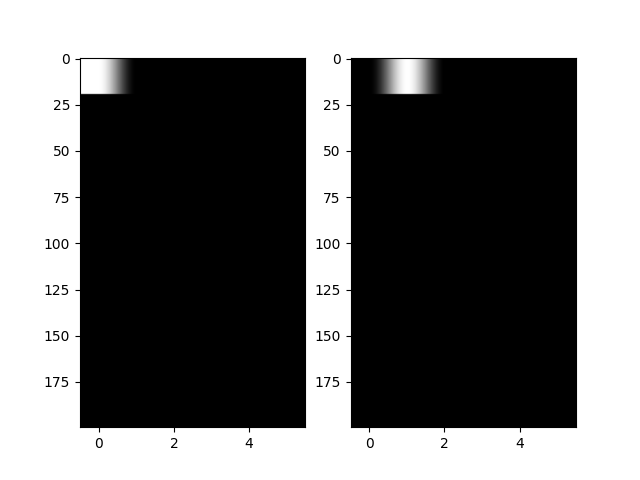

In [8]:
stim = create_stim_center_reach_out(T_STEPS, PULSE_LENGTH, TARGETS)
display(stim.shape)
fig, axes = plt.subplots(1, 2)
axes[0].imshow(stim[0], aspect='auto', cmap='gray')
axes[1].imshow(stim[1], aspect='auto', cmap='gray')

### Create linear reach out trajectories towards the target

(6, 200, 2)

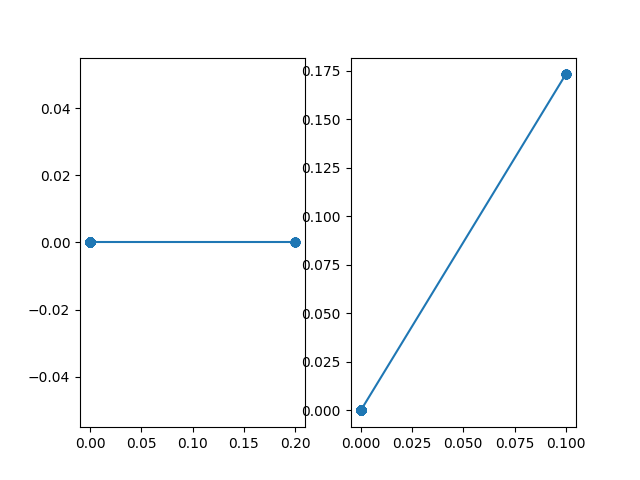

In [9]:
target_traj = create_target_trajectories_center_reach_out(
    T_STEPS, PULSE_LENGTH, TARGETS, TARGET_MAX_RADIUS)
display(target_traj.shape)
fig, axes = plt.subplots(1, 2)
axes[0].plot(target_traj[0][:, 0], target_traj[0][:, 1], "o-")
axes[1].plot(target_traj[1][:, 0], target_traj[1][:, 1], "o-")

### Initialize Neural Network (RNN)

In [10]:
w0

NameError: name 'w0' is not defined

/home/vijay/proj/neural-manifold-and-plasticity/manifolks/rnn.py:38: RuntimeWarning: divide by zero encountered in scalar divide
  self.W *= self.g / np.sqrt(self.K)
/home/vijay/proj/neural-manifold-and-plasticity/manifolks/rnn.py:38: RuntimeWarning: invalid value encountered in multiply
  self.W *= self.g / np.sqrt(self.K)


Text(0.5, 1.0, 'Initial Recurrent Weights')

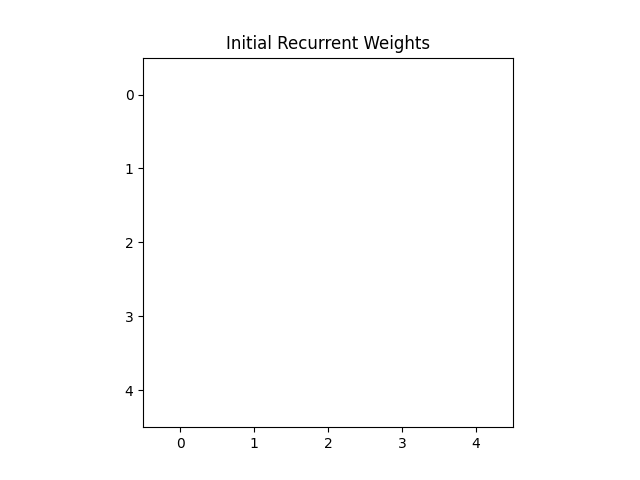

In [11]:
network = RNN(N, g=G, p=P, N_in=TARGETS, dt=DT, tau=TAU)
network.save(OUT_DIR / "rnn")
w0 = network.W.copy()  # randomly initialized weights

# plot the initial weights
fig, ax = plt.subplots(1, 1)
ax.imshow(w0, cmap='gray', vmin=-1, vmax=1)
ax.set_title("Initial Recurrent Weights")